<a href="https://colab.research.google.com/github/Tuchobm/Curso-IA-Google-Colab/blob/main/2_1_clasificador_results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Ejercicio 1: Exploración del Dataset

En este ejercicio, explora el dataset Iris. El dataset Iris es un conjunto de datos clásico en el campo del aprendizaje automático y la estadística. Contiene información sobre tres especies de flores Iris (Iris setosa, Iris versicolor e Iris virginica) y se utiliza comúnmente para la clasificación.

El dataset contiene 150 muestras y 4 características: longitud del sépalo, ancho del sépalo, longitud del pétalo y ancho del pétalo. Cada muestra está etiquetada con la especie de Iris a la que pertenece.

Además, encontrarás partes del código contendrán el comentario de `# ACTIVIDAD` que indican dónde debes completar el código o realizar tareas específicas. Asegúrate de seguir las instrucciones y completar el código donde se indique. Finalmente, en el final de este ejercicio, deberás responder a una serie de preguntas.

## Importar librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Importamos los diferentes modelos de clasificación que hemos visto
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier

In [ ]:
# Aseguramos que los resultados sean reproducibles
np.random.seed(0)

## Carga de datos

In [ ]:
# Nombre de la etiqueta a predecir
INT_TO_LABEL = {0: "setosa", 1: "versicolor", 2: "virginica"}
LABEL_TO_INT = {"setosa": 0, "versicolor": 1, "virginica": 2}

In [ ]:
data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)

# Añadir la columna de etiquetas a predecir
df["target"] = data.target
df["target"] = df["target"].map(INT_TO_LABEL)

entrenamiento, prueba = train_test_split(df, test_size=0.2, random_state=0)
entrenamiento = entrenamiento.reset_index(drop=True)
prueba = prueba.reset_index(drop=True)

# Mostrar las primeras filas del dataset de entrenamiento
print("Dataset de entrenamiento:")
entrenamiento.head()

Dataset de entrenamiento:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,6.4,3.1,5.5,1.8,virginica
1,5.4,3.0,4.5,1.5,versicolor
2,5.2,3.5,1.5,0.2,setosa
3,6.1,3.0,4.9,1.8,virginica
4,6.4,2.8,5.6,2.2,virginica


In [ ]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


# Visualización de datos

El primer grafico muestra la correlación entre las características del dataset Iris. La correlación es una medida estadística que indica la relación entre dos variables. En este caso, estamos interesados en la relación entre las características de las flores Iris.

El segundo gráfico muestra la cantidad de muestras de cada especie que hay en función de cada una de las características. En este caso, estamos utilizando un gráfico de densidad para visualizar la distribución de las características.

Haz doble clic aquí para ver la pista de la actividad a continuación.
<!-- Busca en internet "Como calcular la correlación entre variables en pandas" -->

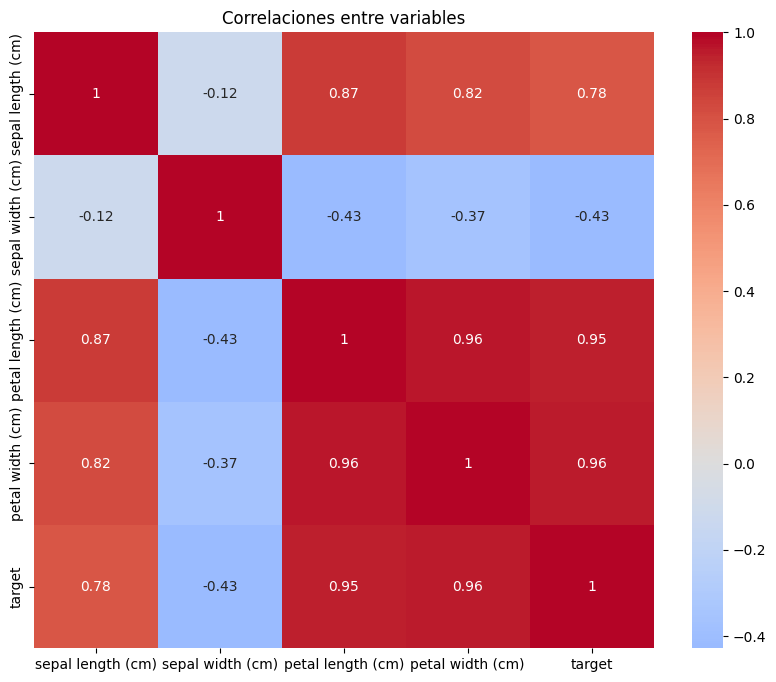

In [ ]:
df_corr = df.copy()
df_corr["target"] = df_corr["target"].map(LABEL_TO_INT)

# ACTIVIDAD: Encontrar la correlación entre las variables
correlation = df_corr.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap="coolwarm", center=0)
plt.title("Correlaciones entre variables")
plt.show()

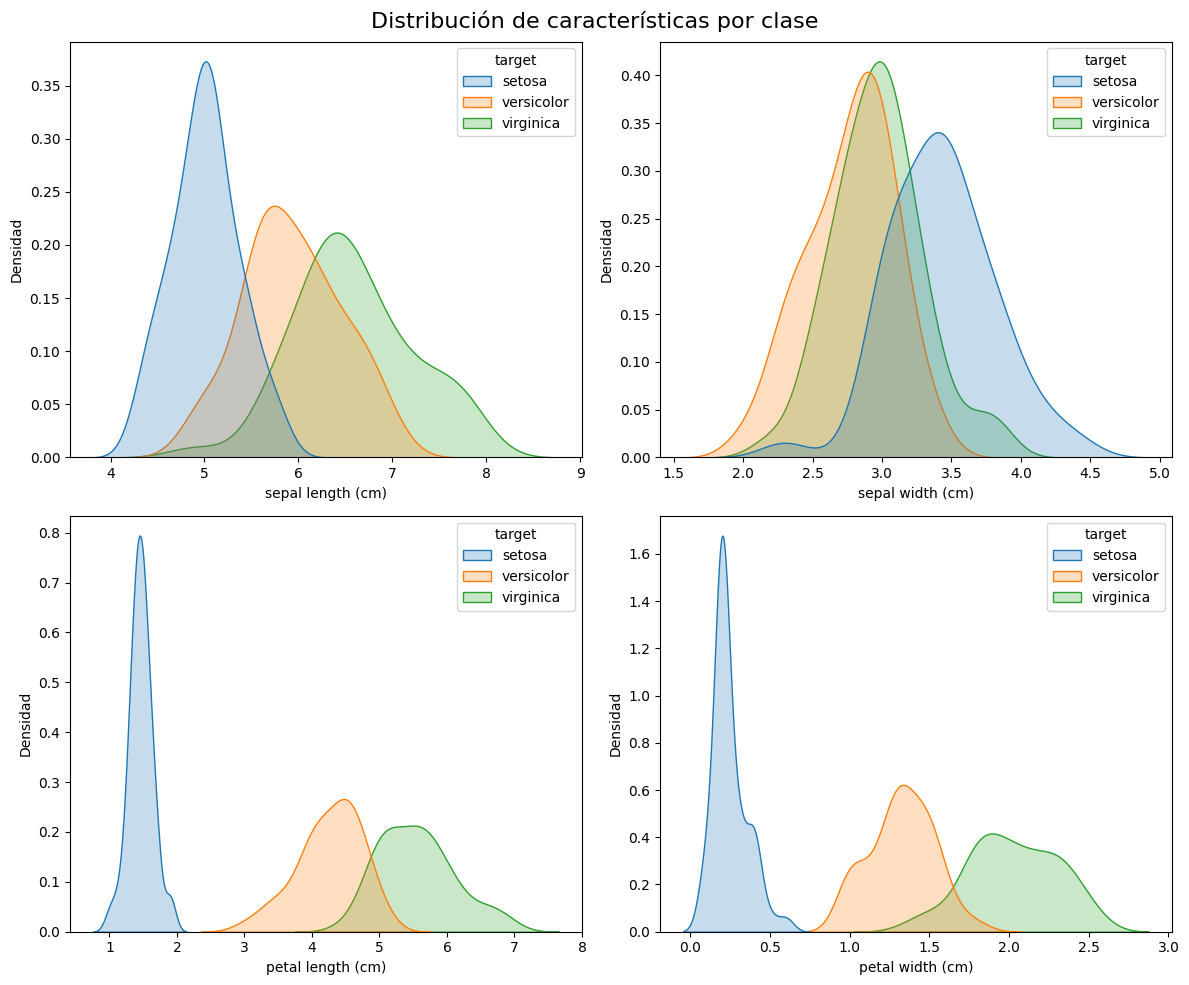

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for i, feature in enumerate(data.feature_names):
    ax = axes[i // 2, i % 2]
    sns.kdeplot(data=df, x=feature, hue="target", ax=ax, fill=True)
    ax.set_xlabel(feature)
    ax.set_ylabel("Densidad")
fig.suptitle("Distribución de características por clase", fontsize=16)
plt.tight_layout()
plt.show()

# Entrenamiento

Prueba de entrenar los modelos mencionados en las presentaciones y encuentra cuál es el mejor modelo para el dataset Iris. Puedes usar los siguientes modelos:
- LogisticRegression
- SVM (SVC en sklearn)
- DecisionTreeClassifier
- RandomForestClassifier
- AdaboostClassifier
- KNeighborsClassifier

In [ ]:
def train(model):
    """Entrena el modelo con los datos de entrenamiento."""
    X_train = entrenamiento.drop(columns=["target"])
    y_train = entrenamiento["target"].map(LABEL_TO_INT)

    model.fit(X_train, y_train)
    print("Modelo entrenado.")
    print(f"Accuracy en entrenamiento: {model.score(X_train, y_train):.2f}")

In [ ]:
# Ejemplo: Modelo simple que predice siempre la clase más frecuente
model = DummyClassifier(strategy="most_frequent")
train(model)

# ACTIVIDAD: Probar diferentes modelos de clasificación
models = {
    "Logistic Regression": LogisticRegression(),
    "SVC": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "KNN": KNeighborsClassifier(),
}
model = models["Logistic Regression"]
for name, model in models.items():
    print(f"Entrenando modelo: {name}")
    train(model)

# ACTIVIDAD OPCIONAL (AVANZADO): Probar diferentes hiperparámetros para cada modelo

Modelo entrenado.
Accuracy en entrenamiento: 0.37
Entrenando modelo: Logistic Regression
Modelo entrenado.
Accuracy en entrenamiento: 0.97
Entrenando modelo: SVC
Modelo entrenado.
Accuracy en entrenamiento: 0.96
Entrenando modelo: Decision Tree
Modelo entrenado.
Accuracy en entrenamiento: 1.00
Entrenando modelo: Random Forest
Modelo entrenado.
Accuracy en entrenamiento: 1.00
Entrenando modelo: AdaBoost
Modelo entrenado.
Accuracy en entrenamiento: 1.00
Entrenando modelo: KNN
Modelo entrenado.
Accuracy en entrenamiento: 0.95


# Evaluación

In [ ]:
from sklearn.metrics import accuracy_score, classification_report


def evaluate(model, df):
    """Evalúa el modelo y muestra la precisión y el reporte de clasificación."""
    X_test = df[data.feature_names]
    y_test = df["target"].map(LABEL_TO_INT)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy del modelo: {accuracy:.2f}")
    print("\nReporte de clasificación:")
    print(classification_report(y_test, y_pred, target_names=INT_TO_LABEL.values()))

In [ ]:
evaluate(model, entrenamiento)

Accuracy del modelo: 0.95

Reporte de clasificación:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        39
  versicolor       0.94      0.89      0.92        37
   virginica       0.91      0.95      0.93        44

    accuracy                           0.95       120
   macro avg       0.95      0.95      0.95       120
weighted avg       0.95      0.95      0.95       120



In [ ]:
# evaluate(model, prueba)
for name, model in models.items():
    print(f"{name}")
    evaluate(model, prueba)

Logistic Regression
Accuracy del modelo: 1.00

Reporte de clasificación:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        11
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00         6

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

SVC
Accuracy del modelo: 1.00

Reporte de clasificación:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        11
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00         6

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Decision Tree
Accuracy del modelo: 1.00

Reporte de clasificación:
              precision    recall  f1-sco

## Preguntas

- Lista el accuracy de cada uno de los modelos en el dataset de entrenamiento y en el de evaluación.

    - **Logistic Regression**
        - Accuracy en entrenamiento: 0.9667
        - Accuracy del modelo: 1.0000

    - **SVC**
        - Accuracy en entrenamiento: 0.9583
        - Accuracy del modelo: 1.0000

    - **Decision Tree**
        - Accuracy en entrenamiento: 1.0000
        - Accuracy del modelo: 1.0000

    - **Random Forest**
        - Accuracy en entrenamiento: 1.0000
        - Accuracy del modelo: 1.0000

    - **AdaBoost**
        - Accuracy en entrenamiento: 1.0000
        - Accuracy del modelo: 0.9667

    - **KNN**
        - Accuracy en entrenamiento: 0.9500
        - Accuracy del modelo: 0.9667

- ¿Qué crees que pasaría si hubiera una mutación en alguna de las especies de Iris?
    - Si hubiera una mutación en alguna de las especies de Iris, el modelo podría no ser capaz de clasificar correctamente la especie afectada. Esto se debe a que el modelo no ha sido entrenado con esta nueva información y, por lo tanto, seguiría basándose en los patrones aprendidos de los datos originales. Esto podría llevar a una disminución en la precisión del modelo y a un aumento en la tasa de error.

- ¿Qué pasaría si el dataset tuviera más datos?
    - Si el dataset tuviera más datos, el modelo podría beneficiarse de una mayor cantidad de información para aprender. Esto podría llevar a una mejora en la precisión del modelo y a una mejor capacidad de generalización. Sin embargo, también podría aumentar el tiempo de entrenamiento.

- ¿Por qué son los resultados de accuracy entre el entrenamiento y la evaluación diferentes? ¿En general, cuál tendrá un accuracy más alto?
    - Los resultados de accuracy entre el entrenamiento y la evaluación son diferentes porque los datos de entrenamiento y evaluación son diferentes. El modelo se entrena en el conjunto de entrenamiento y, por lo tanto, tiene un mejor rendimiento en esos datos.

- ¿Qué significa un valor de accuracy alto en el entrenamiento y bajo en la evaluación?
    - Significa overfitting.

(Si haces doble clic en esta celda, podrás escribir tu respuesta en texto plano.)